In [1]:
%matplotlib inline
import statsmodels as sm
import researchpy as rp
import regex as re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
plt.style.use('_mpl-gallery')

In [2]:
air = pd.read_csv('BaytownAQIJan-April.csv', low_memory=False)
water = pd.read_csv('waterdatadaily.csv', low_memory=False)
salt = pd.read_csv('FISH_seawater_salinity_fix.csv', low_memory=False)

In [3]:
plt.rcParams['figure.figsize'] = [15, 10]

# Exploratory Data Analysis

In [4]:
salt.info()
salt.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  4200 non-null   object 
 1   value     4200 non-null   float64
dtypes: float64(1), object(1)
memory usage: 65.8+ KB


,datetime,value
0,2009-03-17T19:00:00-0500,19.861857
1,2009-03-18T19:00:00-0500,19.976167
2,2009-03-19T19:00:00-0500,18.484833
3,2009-03-20T19:00:00-0500,16.466458
4,2009-03-21T19:00:00-0500,15.054917
5,2009-03-22T19:00:00-0500,17.978167
6,2009-03-23T19:00:00-0500,13.784667
7,2009-03-24T19:00:00-0500,11.491292
8,2009-03-25T19:00:00-0500,11.501208
9,2009-03-26T19:00:00-0500,13.570458


In [5]:
air.info()
air.head(109)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   created_at        109 non-null    object 
 1   PM1.0_CF1_ug/m3   109 non-null    float64
 2   PM2.5_CF1_ug/m3   109 non-null    float64
 3   PM10.0_CF1_ug/m3  109 non-null    float64
 4   UptimeMinutes     109 non-null    float64
 5   RSSI_dbm          109 non-null    float64
 6   Temperature_F     109 non-null    float64
 7   Humidity_%        109 non-null    float64
 8   PM2.5_ATM_ug/m3   109 non-null    float64
 9   Unnamed: 9        0 non-null      float64
dtypes: float64(9), object(1)
memory usage: 8.6+ KB


,created_at,PM1.0_CF1_ug/m3,PM2.5_CF1_ug/m3,PM10.0_CF1_ug/m3,UptimeMinutes,RSSI_dbm,Temperature_F,Humidity_%,PM2.5_ATM_ug/m3,Unnamed: 9
0,2022-01-01 00:00:00 UTC,14.03,21.08,22.75,36976.44,-52.97,83.04,60.03,20.13,NaN
1,2022-01-02 00:00:00 UTC,13.94,21.40,22.83,38416.00,-53.51,60.75,47.67,18.21,NaN
2,2022-01-03 00:00:00 UTC,2.90,3.91,4.28,39855.00,-53.41,51.30,35.33,3.91,NaN
3,2022-01-04 00:00:00 UTC,29.20,42.21,45.71,41295.00,-53.39,57.26,45.67,33.89,NaN
4,2022-01-05 00:00:00 UTC,13.69,19.25,20.48,42735.01,-59.03,70.62,54.42,16.43,NaN
...,...,...,...,...,...,...,...,...,...,...
104,2022-03-30 00:00:00 UTC,6.52,9.81,11.18,18002.00,-53.97,79.29,57.00,9.79,NaN
105,2022-03-30 00:00:00 UTC,6.52,9.81,11.18,18002.00,-53.97,79.29,57.00,9.79,NaN
106,2022-03-31 00:00:00 UTC,6.81,8.51,8.92,19442.11,-54.29,72.41,34.49,8.51,NaN
107,2022-03-31 00:00:00 UTC,6.81,8.51,8.92,19442.11,-54.29,72.41,34.49,8.51,NaN


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>], dtype=object)

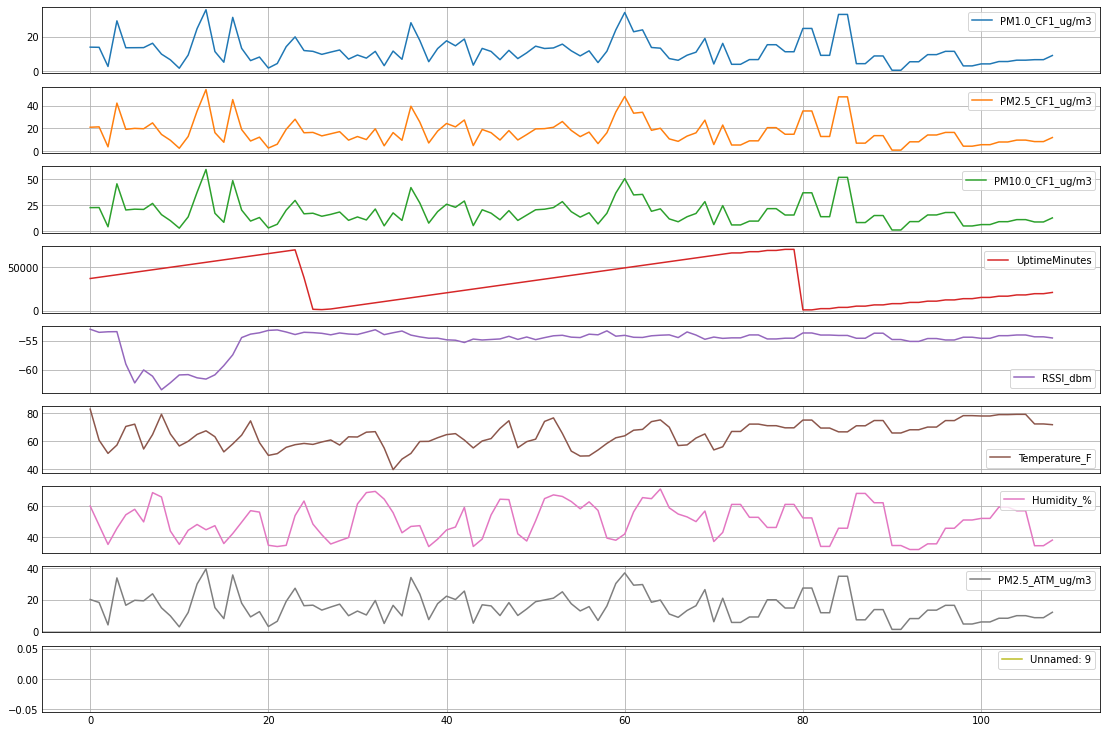

In [6]:
air.plot(subplots=True)

In [7]:
air.describe()
air.nunique()

created_at          91
PM1.0_CF1_ug/m3     88
PM2.5_CF1_ug/m3     90
PM10.0_CF1_ug/m3    90
UptimeMinutes       91
RSSI_dbm            82
Temperature_F       91
Humidity_%          91
PM2.5_ATM_ug/m3     89
Unnamed: 9           0
dtype: int64

In [8]:
water.info()
water.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column                                                     Non-Null Count  Dtype 
---  ------                                                     --------------  ----- 
 0   Date                                                       92 non-null     object
 1   Temper- ature, water, deg C,(Maximum)                      92 non-null     object
 2   Temper- ature, water, deg C,(Minimum)                      92 non-null     object
 3   Temper- ature, water, deg C,(Mean)                         92 non-null     object
 4   Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Maximum)  91 non-null     object
 5   Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Minimum)  91 non-null     object
 6   Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Mean)     91 non-null     object
 7   pH, water,unfltrd field,  std units,(Maximum)              92 non-null     object
 8   pH, water,unfltrd fiel

,Date,"Temper- ature, water, deg C,(Maximum)","Temper- ature, water, deg C,(Minimum)","Temper- ature, water, deg C,(Mean)","Specif- icconduc- tance,wat unfuS/cm @25 degC,(Maximum)","Specif- icconduc- tance,wat unfuS/cm @25 degC,(Minimum)","Specif- icconduc- tance,wat unfuS/cm @25 degC,(Mean)","pH, water,unfltrd field, std units,(Maximum)","pH, water,unfltrd field, std units,(Minimum)","pH, water,unfltrd field, std units,(Median)","Dis- solvedoxygen, mg/L,(Maximum)","Dis- solvedoxygen, mg/L,(Minimum)","Dis- solvedoxygen, mg/L,(Mean)","Turbid- ity, IR LED light,det ang90 deg, FNU,(Mean)","Turbid- ity, IR LED light,det ang90 deg, FNU,(Minimum)","Turbid- ity, IR LED light,det ang90 deg, FNU,(Maximum)"
0,(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i),(i)
1,01/01/2022,21.7A,21.0A,21.3A,371A,369A,370A,8.1A,7.9A,8.0A,8.4A,8.0A,8.1A,15.7A,14.0A,17.5A
2,01/02/2022,21.4A,18.1A,19.9A,378A,368A,371A,8.1A,8.0A,8.0A,8.7A,8.0A,8.3A,17.6A,14.6A,19.8A
3,01/03/2022,18.5A,16.8A,17.6A,374A,370A,372A,8.1A,8.0A,8.0A,9.0A,8.6A,8.7A,15.8A,13.9A,17.4A
4,01/04/2022,17.2A,16.0A,16.5A,376A,372A,374A,8.1A,8.0A,8.0A,9.3A,8.7A,9.0A,15.3A,13.6A,16.4A


# Data Wrangling 

In [9]:
salt.rename(columns = {'datetime': 'Date'}, inplace=True)
salt['Date'] = pd.to_datetime(salt['Date'], utc=True)

In [10]:
salt.info()
salt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    4200 non-null   datetime64[ns, UTC]
 1   value   4200 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 65.8 KB


,Date,value
0,2009-03-18 00:00:00+00:00,19.861857
1,2009-03-19 00:00:00+00:00,19.976167
2,2009-03-20 00:00:00+00:00,18.484833
3,2009-03-21 00:00:00+00:00,16.466458
4,2009-03-22 00:00:00+00:00,15.054917


In [11]:
water.rename(columns = {
    'Temper- ature, water, deg C,(Maximum)':'Water Temperature Celsius (Max)',
    'Temper- ature, water, deg C,(Minimum)':'Water Temperature Celsius (Min)',
    'Temper- ature, water, deg C,(Mean)':'Water Temperature Celsius (Mean)',
    'Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Maximum)':'Specific Conductance in μS/cm (Max)',
    'Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Minimum)':'Specific Conductance in μS/cm (Min)',
    'Specif-   icconduc- tance,wat unfuS/cm @25 degC,(Mean)':'Specific Conductance in μS/cm (Mean)',
    'pH, water,unfltrd field,  std units,(Maximum)': 'pH Level (Max)',
    'pH, water,unfltrd field,  std units,(Minimum)':'pH Level (Min)',
    'pH, water,unfltrd field,  std units,(Median)': 'pH Level (Median)',
    'Dis- solvedoxygen,  mg/L,(Maximum)': 'Dissolved Oxygen in mg/L (Max)',
    'Dis- solvedoxygen,  mg/L,(Minimum)': 'Dissolved Oxygen in mg/L (Min)',
    'Dis- solvedoxygen,  mg/L,(Mean)': 'Dissolved Oxygen in mg/L (Mean)',
    'Turbid-  ity, IR LED light,det ang90 deg,  FNU,(Mean)':'Turbidity in FNU (Mean)',
    'Turbid-  ity, IR LED light,det ang90 deg,  FNU,(Minimum)':'Turbidity in FNU (Min)',
    'Turbid-  ity, IR LED light,det ang90 deg,  FNU,(Maximum)':'Turbidity in FNU (Max)'
}, inplace = True)
water = water.drop([0,0])
water['Date'] = pd.to_datetime(water['Date'])

In [12]:
water[water.columns[1:]] = water[water.columns[1:]].replace('[A-Z]','', regex=True).astype(float)
water.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91 entries, 1 to 91
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  91 non-null     datetime64[ns]
 1   Water Temperature Celsius (Max)       91 non-null     float64       
 2   Water Temperature Celsius (Min)       91 non-null     float64       
 3   Water Temperature Celsius (Mean)      91 non-null     float64       
 4   Specific Conductance in μS/cm (Max)   90 non-null     float64       
 5   Specific Conductance in μS/cm (Min)   90 non-null     float64       
 6   Specific Conductance in μS/cm (Mean)  90 non-null     float64       
 7   pH Level (Max)                        91 non-null     float64       
 8   pH Level (Min)                        91 non-null     float64       
 9   pH Level (Median)                     91 non-null     float64       
 10  Diss

In [13]:
air.drop(columns=['Unnamed: 9'], inplace=True)

In [14]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   created_at        109 non-null    object 
 1   PM1.0_CF1_ug/m3   109 non-null    float64
 2   PM2.5_CF1_ug/m3   109 non-null    float64
 3   PM10.0_CF1_ug/m3  109 non-null    float64
 4   UptimeMinutes     109 non-null    float64
 5   RSSI_dbm          109 non-null    float64
 6   Temperature_F     109 non-null    float64
 7   Humidity_%        109 non-null    float64
 8   PM2.5_ATM_ug/m3   109 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.8+ KB


In [15]:
air.rename(columns = {'created_at': 'Date'}, inplace=True)
air['Date'] = pd.to_datetime(air['Date'])

In [16]:
air.info()
air['Date'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Date              109 non-null    datetime64[ns, UTC]
 1   PM1.0_CF1_ug/m3   109 non-null    float64            
 2   PM2.5_CF1_ug/m3   109 non-null    float64            
 3   PM10.0_CF1_ug/m3  109 non-null    float64            
 4   UptimeMinutes     109 non-null    float64            
 5   RSSI_dbm          109 non-null    float64            
 6   Temperature_F     109 non-null    float64            
 7   Humidity_%        109 non-null    float64            
 8   PM2.5_ATM_ug/m3   109 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(8)
memory usage: 7.8 KB


91

In [17]:
air.Date

0     2022-01-01 00:00:00+00:00
1     2022-01-02 00:00:00+00:00
2     2022-01-03 00:00:00+00:00
3     2022-01-04 00:00:00+00:00
4     2022-01-05 00:00:00+00:00
                 ...           
104   2022-03-30 00:00:00+00:00
105   2022-03-30 00:00:00+00:00
106   2022-03-31 00:00:00+00:00
107   2022-03-31 00:00:00+00:00
108   2022-04-01 00:00:00+00:00
Name: Date, Length: 109, dtype: datetime64[ns, UTC]

In [18]:
air.drop_duplicates(subset=['Date'], keep='first', inplace=True)
air.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91 entries, 0 to 108
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Date              91 non-null     datetime64[ns, UTC]
 1   PM1.0_CF1_ug/m3   91 non-null     float64            
 2   PM2.5_CF1_ug/m3   91 non-null     float64            
 3   PM10.0_CF1_ug/m3  91 non-null     float64            
 4   UptimeMinutes     91 non-null     float64            
 5   RSSI_dbm          91 non-null     float64            
 6   Temperature_F     91 non-null     float64            
 7   Humidity_%        91 non-null     float64            
 8   PM2.5_ATM_ug/m3   91 non-null     float64            
dtypes: datetime64[ns, UTC](1), float64(8)
memory usage: 7.1 KB


<AxesSubplot:xlabel='Date'>

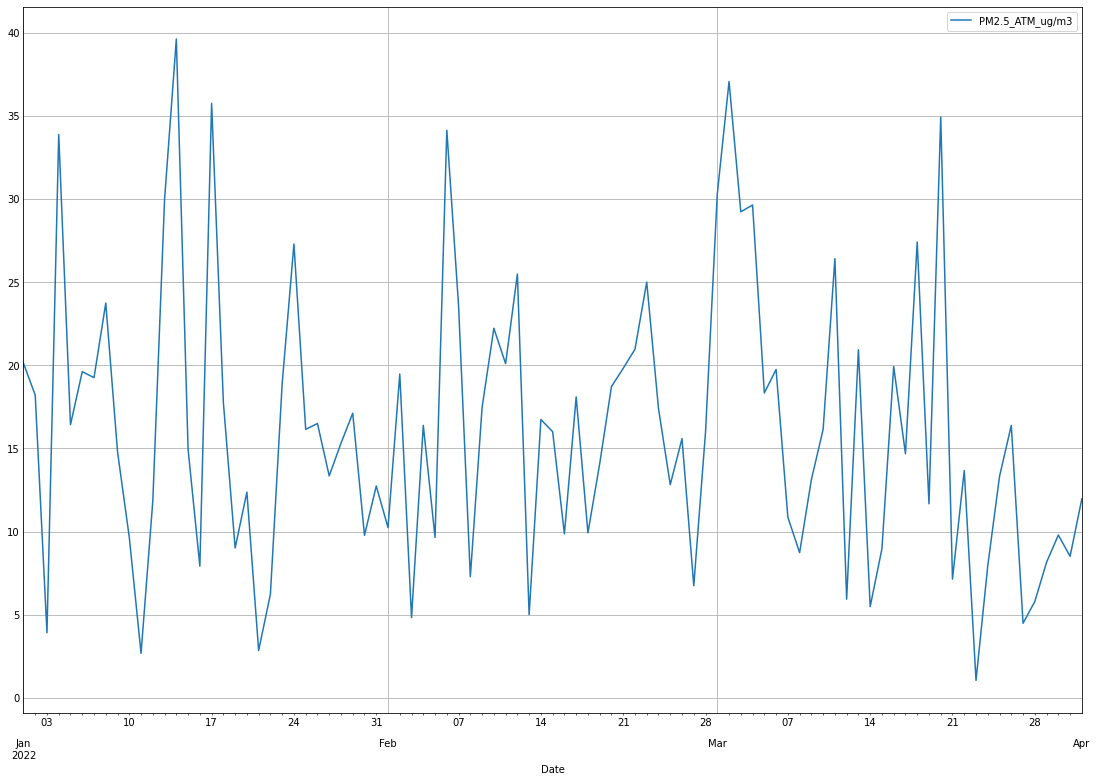

In [19]:
air.plot(x='Date', y='PM2.5_ATM_ug/m3')

<AxesSubplot:xlabel='Date'>

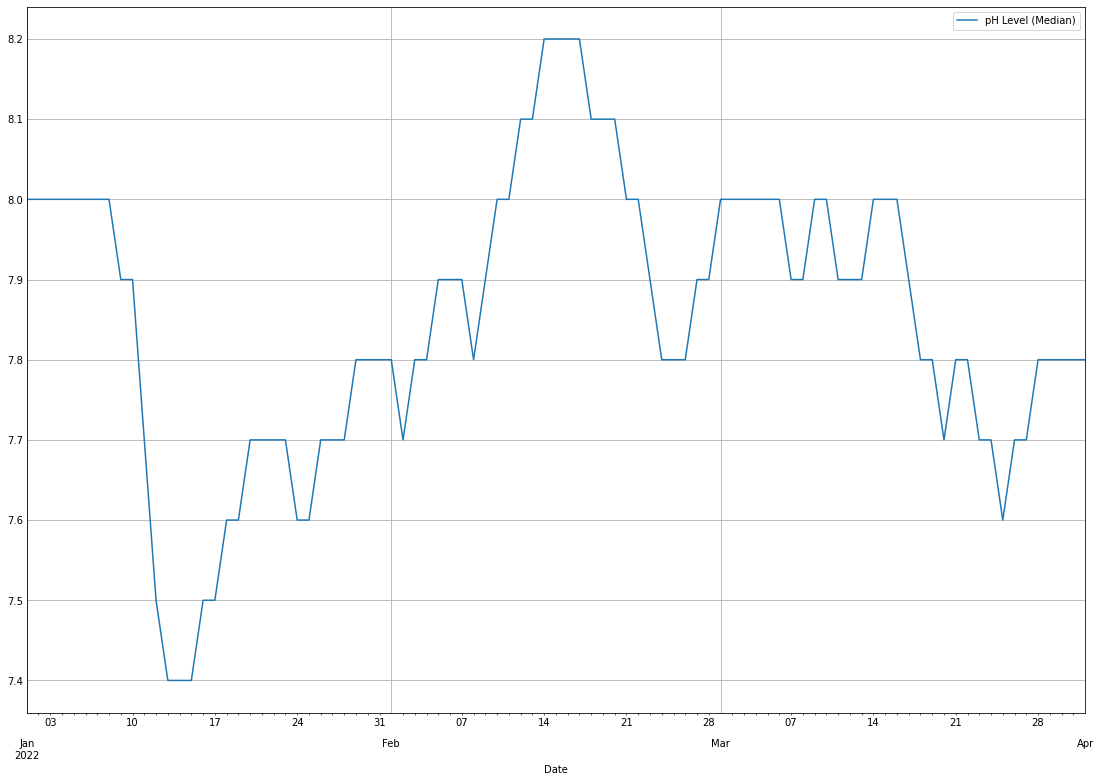

In [20]:
water.plot(x = 'Date',
          y = 'pH Level (Median)')

array([<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>,
       <AxesSubplot:xlabel='Date'>], dtype=object)

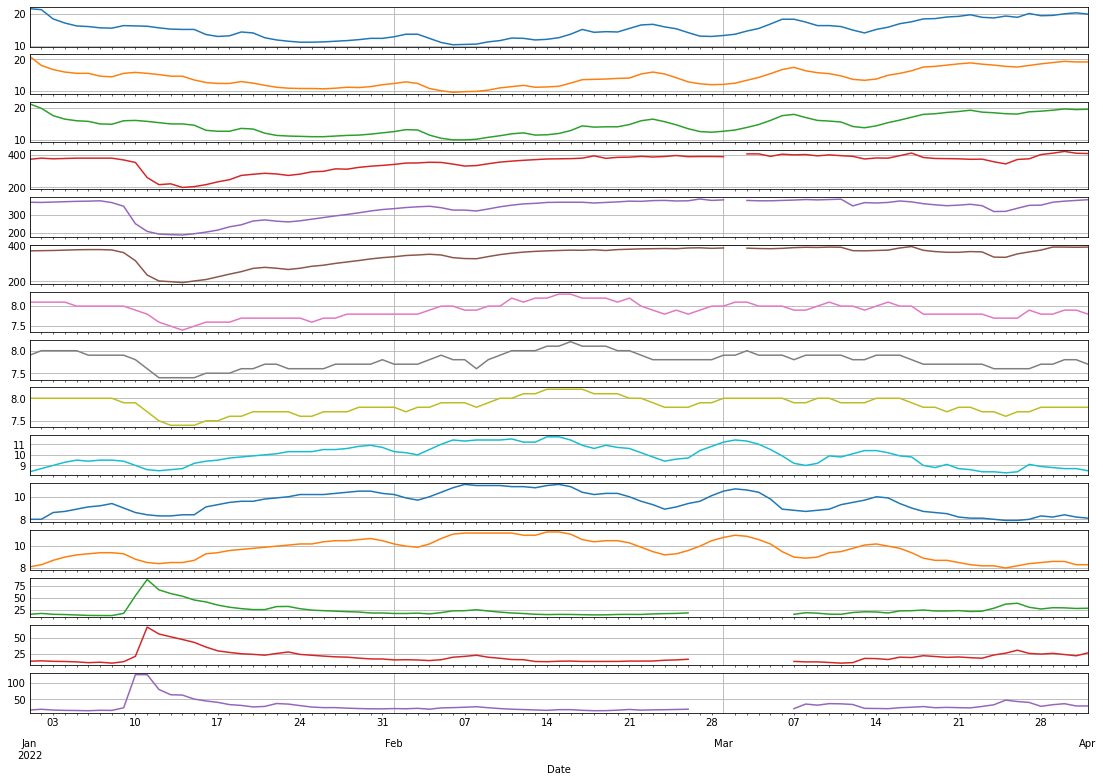

In [21]:
water.plot(subplots=True, x = 'Date', legend=False)

# Statistical Analysis

## Linear Regression

In [22]:
y=air['Temperature_F'].values.reshape(-1,1)
x=water['Dissolved Oxygen in mg/L (Mean)'].values.reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred = lin_reg.predict(x)

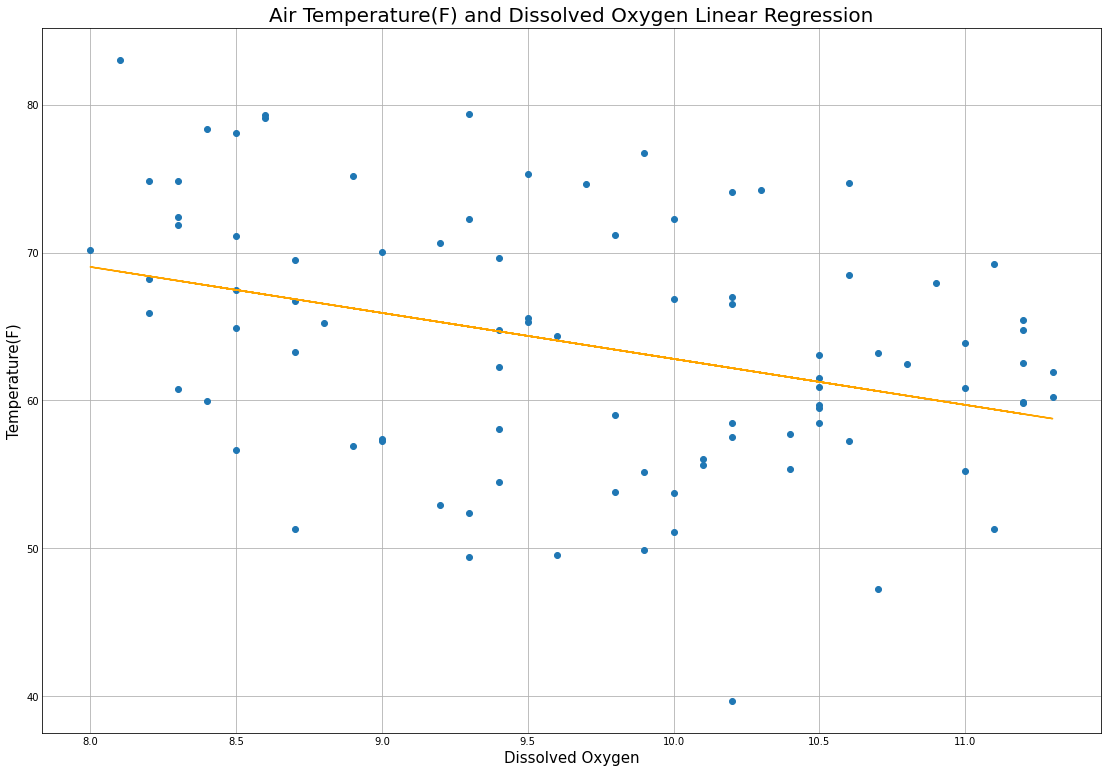

In [23]:
plt.scatter(x,y)
plt.plot(x,y_pred, color='Orange')
plt.title(label='Air Temperature(F) and Dissolved Oxygen Linear Regression', fontsize=20)
plt.ylabel('Temperature(F)', fontsize=15)
plt.xlabel('Dissolved Oxygen', fontsize=15)
plt.show()

In [24]:
y=water['pH Level (Median)'].values.reshape(-1,1)
x=air['PM2.5_ATM_ug/m3'].values.reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred = lin_reg.predict(x)
print("Coefficients: \n", lin_reg.coef_)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y,y_pred))

# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y,y_pred))

Coefficients: 
 [[0.00055157]]
Mean squared error: 0.03
Coefficient of determination: 0.00


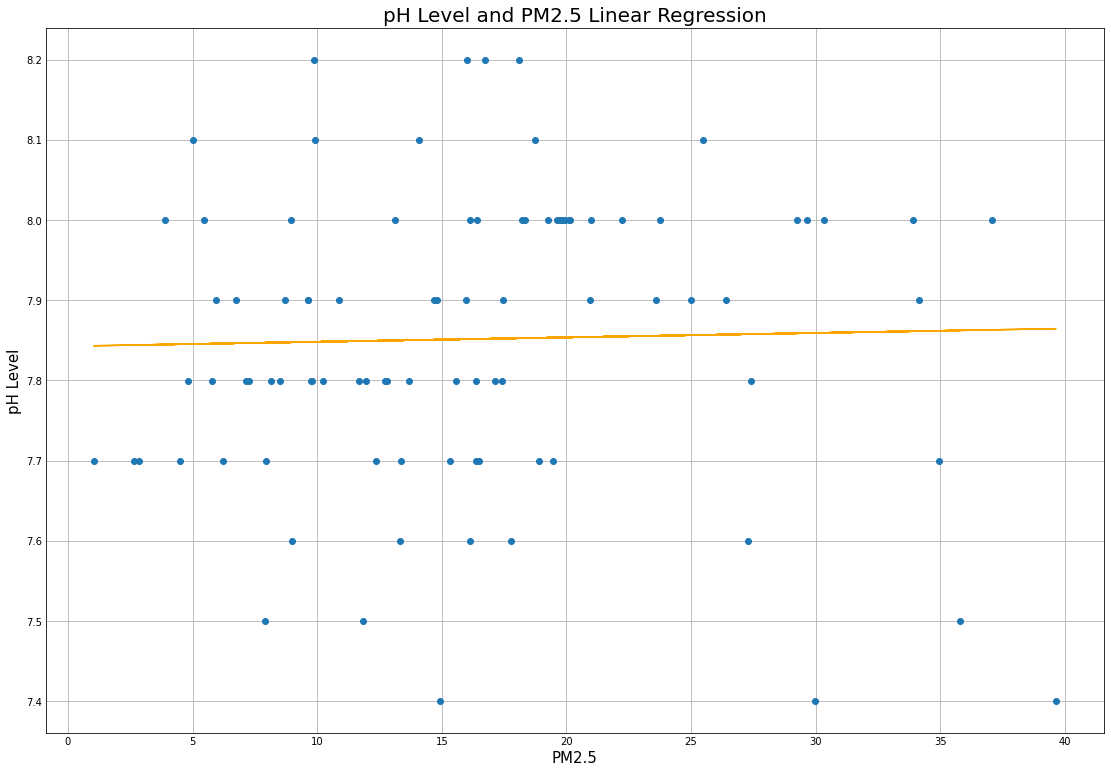

In [25]:
plt.scatter(x,y)
plt.plot(x,y_pred, color='Orange')
plt.title(label='pH Level and PM2.5 Linear Regression', fontsize=20)
plt.ylabel('pH Level', fontsize=15)
plt.xlabel('PM2.5', fontsize=15)
plt.show()

In [26]:
y=water['Dissolved Oxygen in mg/L (Mean)'].values.reshape(-1,1)
x=air['PM2.5_ATM_ug/m3'].values.reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred = lin_reg.predict(x)
print("Coefficients: \n", lin_reg.coef_)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y,y_pred))

# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y,y_pred))

Coefficients: 
 [[0.02093661]]
Mean squared error: 0.87
Coefficient of determination: 0.04


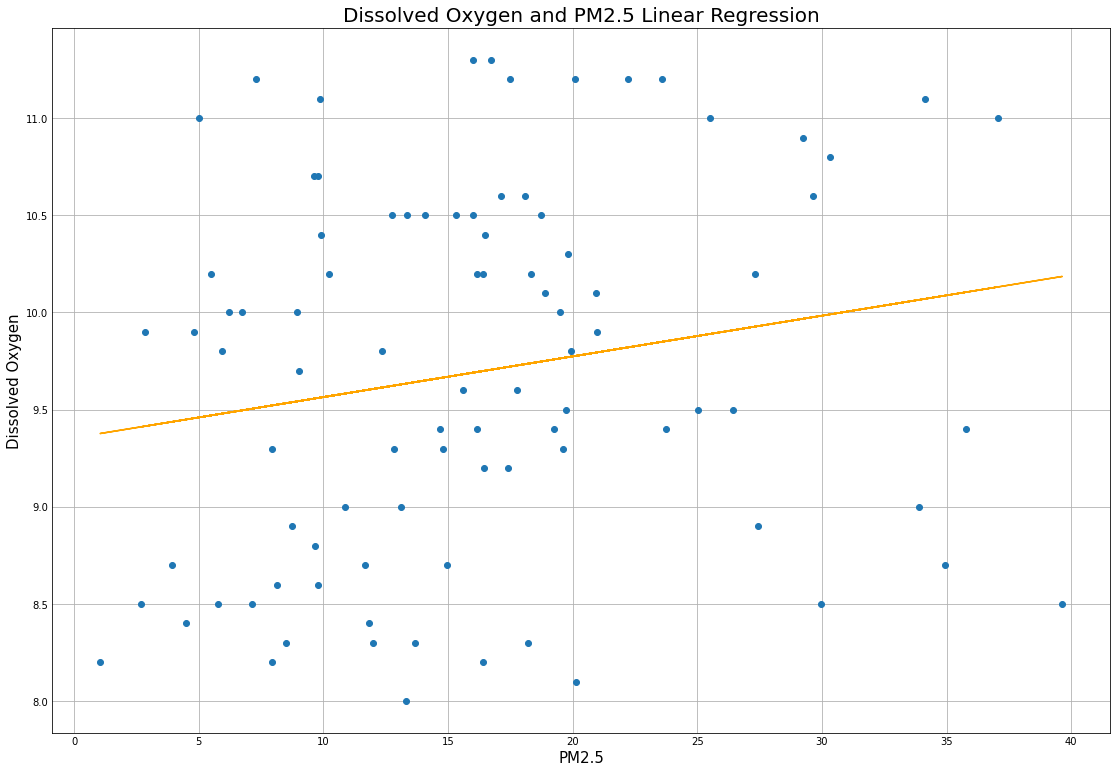

In [27]:
plt.scatter(x,y)
plt.plot(x,y_pred, color='Orange')
plt.title(label='Dissolved Oxygen and PM2.5 Linear Regression', fontsize=20)
plt.ylabel('Dissolved Oxygen', fontsize=15)
plt.xlabel('PM2.5', fontsize=15)
plt.show()

## Signifigance

In [28]:
stats.levene(water['Dissolved Oxygen in mg/L (Mean)'], air['PM2.5_ATM_ug/m3'])

LeveneResult(statistic=104.97616170939955, pvalue=1.0673737116497631e-19)

In [29]:
stats.levene(water['pH Level (Median)'], air['PM2.5_ATM_ug/m3'])

LeveneResult(statistic=131.73031573472682, pvalue=3.1042514931475285e-23)

In [30]:
stats.levene(water['pH Level (Median)'], water['Dissolved Oxygen in mg/L (Mean)'])

LeveneResult(statistic=159.9334619640779, pvalue=1.2129837947959641e-26)

## Normal Distribution

(array([ 1.,  4.,  2.,  6.,  5., 16., 19., 12., 15., 11.]),
 array([-2.93679947, -2.48120032, -2.02560117, -1.57000202, -1.11440287,
        -0.65880372, -0.20320457,  0.25239458,  0.70799373,  1.16359288,
         1.61919204]),
 <BarContainer object of 10 artists>)

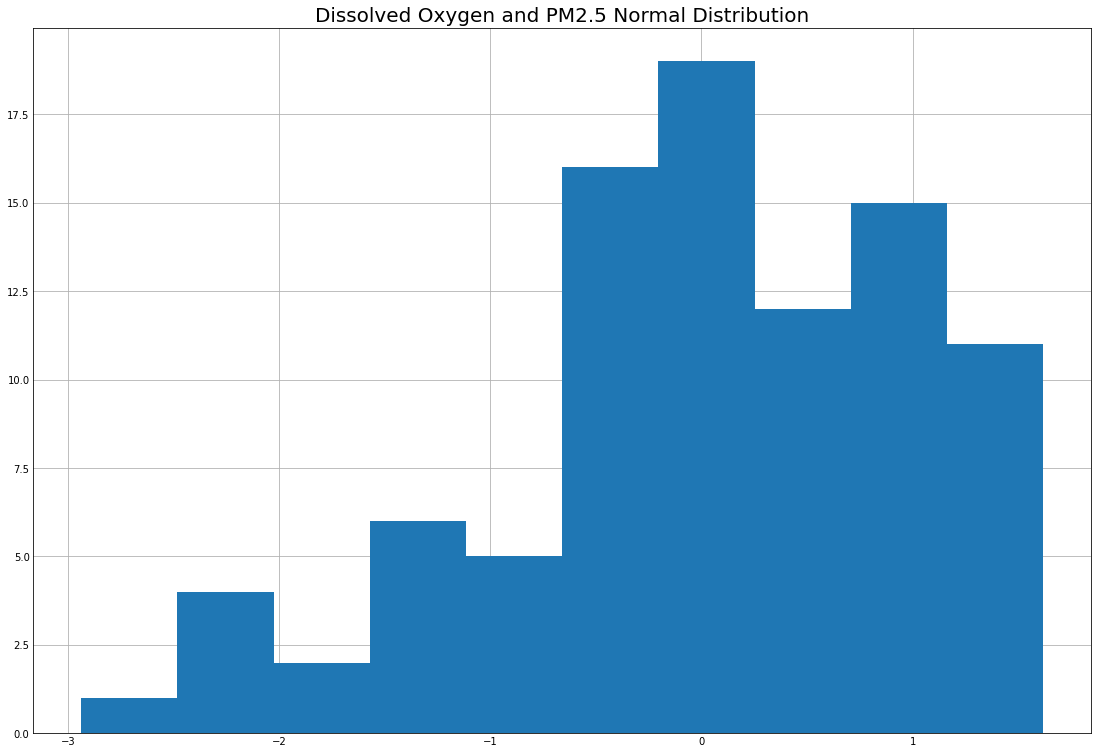

In [31]:
diff = scale(np.array(water['Dissolved Oxygen in mg/L (Mean)'])- np.array(air['PM2.5_ATM_ug/m3']))
plt.title(label='Dissolved Oxygen and PM2.5 Normal Distribution', fontsize=20)
plt.hist(diff)

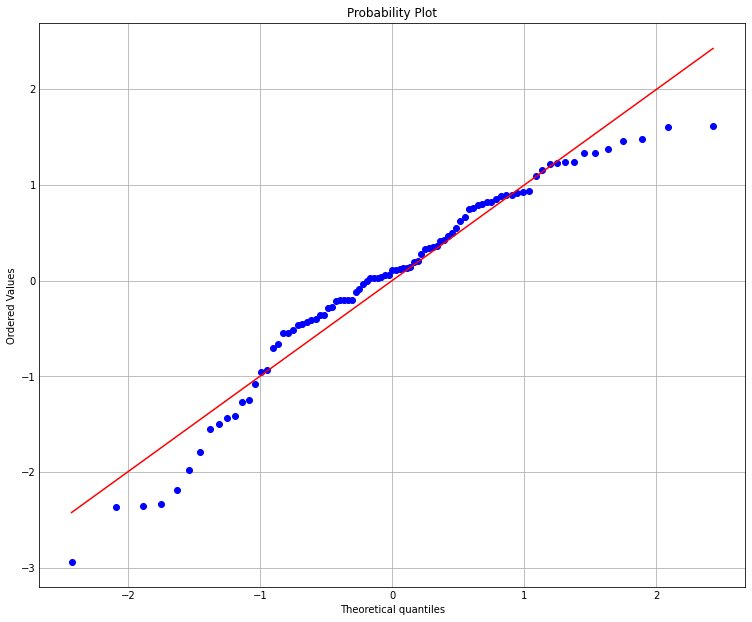

In [32]:
plt.figure(figsize=(10,8))
stats.probplot(diff, plot=plt, dist='norm')
plt.show()

In [33]:
stats.shapiro(diff)

ShapiroResult(statistic=0.9510546922683716, pvalue=0.0018138074083253741)

(array([ 2.,  4.,  4.,  5.,  5., 17., 20., 14., 13.,  7.]),
 array([-2.80720721, -2.35118885, -1.8951705 , -1.43915214, -0.98313378,
        -0.52711543, -0.07109707,  0.38492128,  0.84093964,  1.29695799,
         1.75297635]),
 <BarContainer object of 10 artists>)

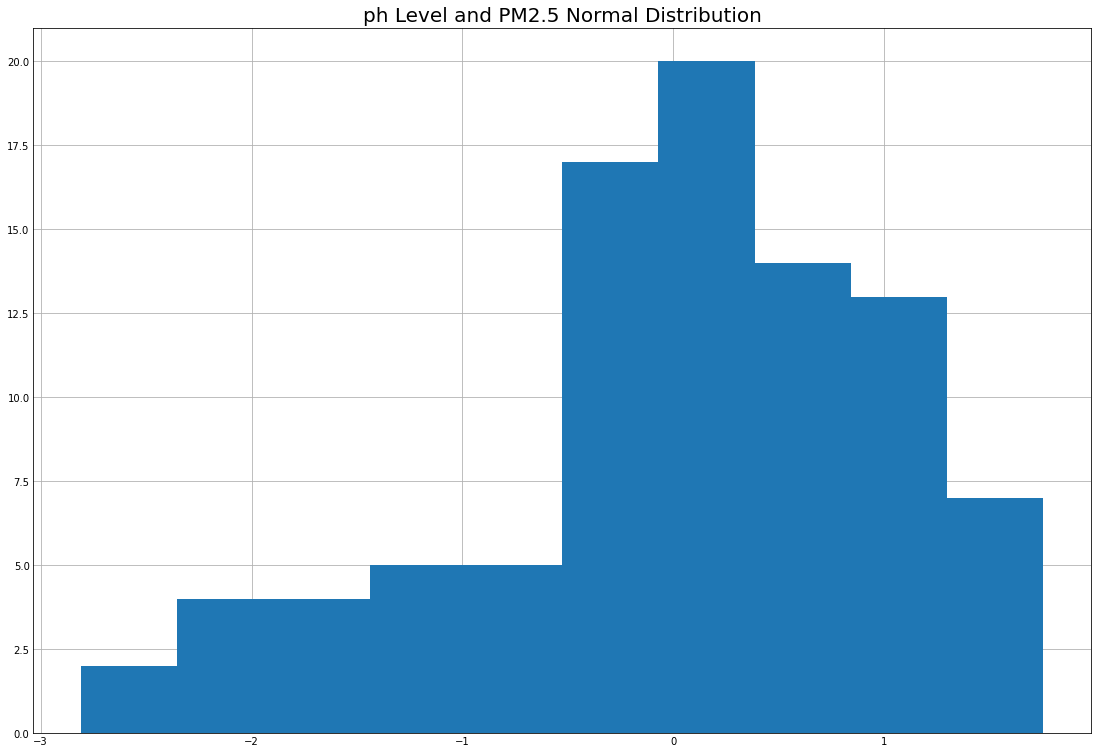

In [34]:
diff = scale(np.array(water['pH Level (Median)'])- np.array(air['PM2.5_ATM_ug/m3']))
plt.title(label='ph Level and PM2.5 Normal Distribution', fontsize=20)
plt.hist(diff)

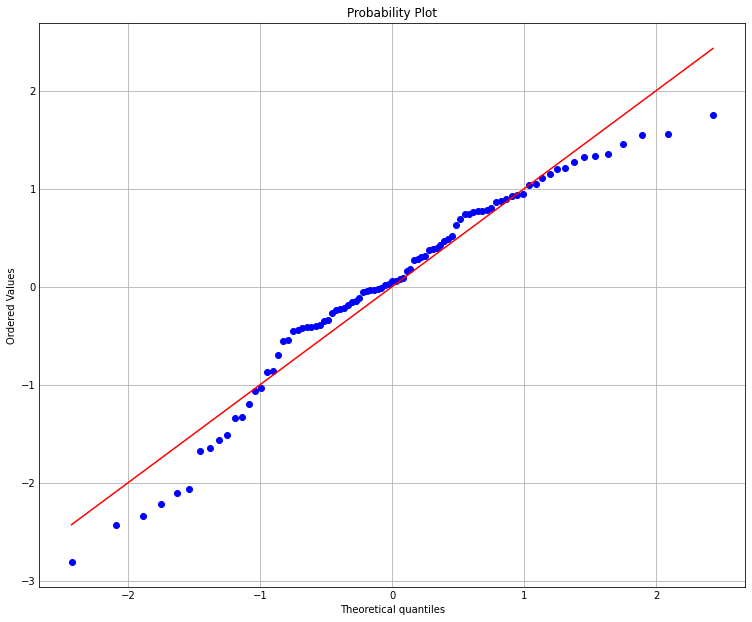

In [35]:
plt.figure(figsize=(10,8))
stats.probplot(diff, plot=plt, dist='norm')
plt.show()

In [36]:
stats.shapiro(diff)

ShapiroResult(statistic=0.9557737112045288, pvalue=0.003625319106504321)